In [5]:
import pandas as pd

In [6]:
import pickle

pickle_file_path = "../data/processed/sample_minocc100/test_graph-node_id.pkl"
with open(pickle_file_path, "rb") as f:
    data = pickle.load(f)


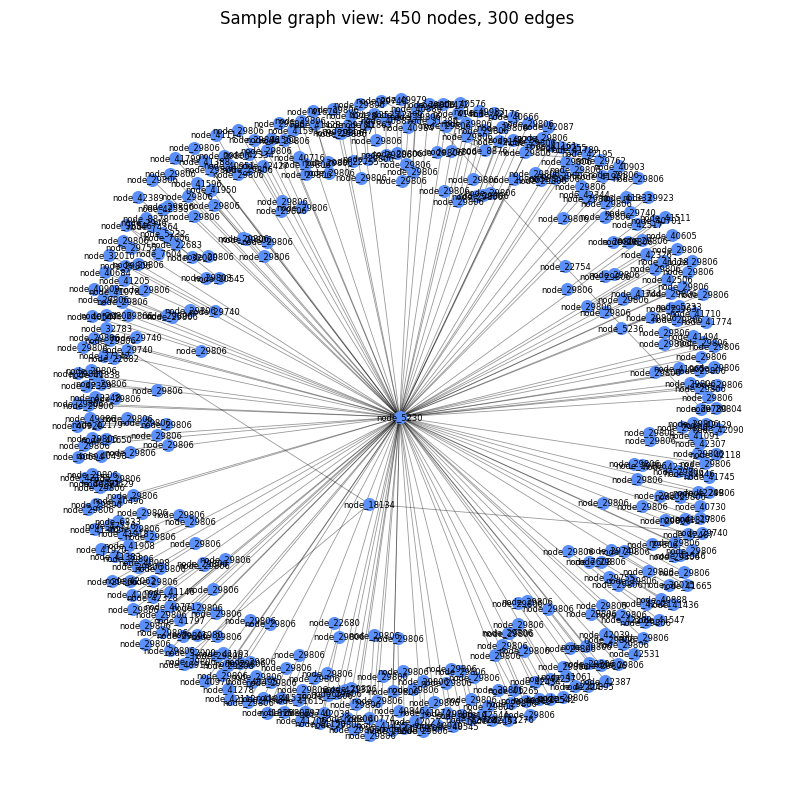

In [7]:
# Visualize a sample of the graph
import matplotlib.pyplot as plt
import networkx as nx
import torch

edge_index = data.edge_index
num_edges = edge_index.size(1)
max_edges = 300
if num_edges > max_edges:
    edge_sample = torch.randperm(num_edges)[:max_edges]
    edge_index_vis = edge_index[:, edge_sample]
else:
    edge_index_vis = edge_index

G = nx.DiGraph()
G.add_edges_from(edge_index_vis.t().tolist())

labels = None
if hasattr(data, "x_names") and data.x_names is not None:
    labels = {i: data.x_names[i] for i in G.nodes if i < len(data.x_names)}

plt.figure(figsize=(10, 10))
pos = nx.spring_layout(G, seed=7)
nx.draw_networkx_nodes(G, pos, node_size=70, node_color="#5b8ff9")
nx.draw_networkx_edges(G, pos, arrows=False, alpha=0.4, width=0.6)
if labels:
    nx.draw_networkx_labels(G, pos, labels=labels, font_size=6)
plt.title(f"Sample graph view: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")
plt.axis("off")
plt.show()


In [8]:
# Write example contents to a markdown file for comparison with docs/05_data_spec.md
import pandas as pd
import pprint

pickle_file_path = "../data/processed/sample_minocc100/test_graph-node_id.pkl"
with open(pickle_file_path, "rb") as f:
    data = pickle.load(f)

graph_fields = list(getattr(data, "keys", lambda: [])())

parquet_path = "../data/interim/sample_minocc100_labeled/df_test.parquet"
df_test = pd.read_parquet(parquet_path)

out_path = "../tmp/sample_minocc100_examples.md"
with open(out_path, "w", encoding="utf-8") as out:
    out.write("# sample_minocc100 examples\n\n")
    out.write("## test_graph-node_id.pkl\n")
    out.write("```\n")
    out.write(str(data))
    out.write("\n```\n\n")
    out.write("**data_fields:**\n")
    out.write("\n```\n")
    out.write(pprint.pformat(graph_fields, width=88))
    out.write("\n```\n\n")
    out.write("## df_test.parquet\n")
    out.write(f"shape: {df_test.shape}\n\n")
    out.write("**columns:**\n")
    out.write("\n```\n")
    out.write(pprint.pformat(list(df_test.columns), width=88))
    out.write("\n```\n\n")
    out.write("**head(3):**\n")
    out.write("\n```\n")
    out.write(df_test.head(3).to_string())
    out.write("\n```\n\n")
    if len(df_test) > 0:
        out.write("**first row (transposed):**\n")
        out.write("\n```\n")
        out.write(df_test.iloc[0].T.to_string())
        out.write("\n```\n")

print(f"Wrote examples to {out_path}")


Wrote examples to ../tmp/sample_minocc100_examples.md
